# Session 5: Cloud Masking and Compositing
**MOOC Series: From Satellite Data to Insights with Digital Earth Sweden**

---

## Session outline

- Why clouds are a fundamental challenge in optical Earth observation
- Masking as a concept: including and excluding pixels
- Sentinel-2 Quality Assurance Information (QAI) layer: a per-pixel quality bits 
- Building a cloud mask from the QAI layer
- Combining cloud masking with temporal reduction to create a cloud-free composite

By the end of this session you will have produced a clean, cloud-free true-color and NDVI composite over Karlstad — the analysis-ready product we will hand to the machine learning classifier in Session 6.

---

## 1. Setup

In [1]:
import openeo
import io
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Connect to Digital Earth Sweden
connection = openeo.connect('https://openeo.digitalearth.se')
connection.authenticate_basic(username='testuser', password='secretpassword')

# Area of interest: Karlstad, Sweden
aoi = {
    'west':  13.460930954751282,
    'east':  13.585449709728213,
    'south': 59.36327761288911,
    'north': 59.40107161575003,
    'crs':   'EPSG:4326',
}

# We use a one-month window to ensure multiple scenes are available
timespan = ['2026-06-01', '2026-07-01']
max_cloud_cover = 20  # Scene-level pre-filter: drop scenes with > 20% cloud cover

print('Connected to Digital Earth Sweden.')

Connected to Digital Earth Sweden.


## 2. Why clouds are such a big problem

Optical satellites like Sentinel-2 measure reflected sunlight. Clouds block or scatter sunlight before it reaches the surface, so any pixel covered by a cloud does **not** contain information about the ground — it contains information about the top of the cloud.

Over Sweden and other high-latitude regions this is especially challenging:

- On average, more than **60% of all Sentinel-2 pixels** over Sweden are cloud-contaminated.
- Some locations in northern Sweden see only a handful of fully clear days per year.
- Even a scene with only 5% cloud cover can completely obscure the area you care about.

Clouds appear as very **bright white** patches in true-color images. Their high reflectance in all visible bands makes them easy to confuse with snow, and their shadows on the ground are almost as problematic as the clouds themselves.

**The solution:** rather than finding one perfect cloud-free scene (which may not exist), we use a time series of multiple scenes and build a **composite** — a single synthetic image assembled from the cloud-free pixels of different dates.

## 3. A scene with clouds

Before we fix the cloud problem, let us look at what a typical cloudy scene looks like. We load a single Sentinel-2 scene that is known to contain cloud cover.

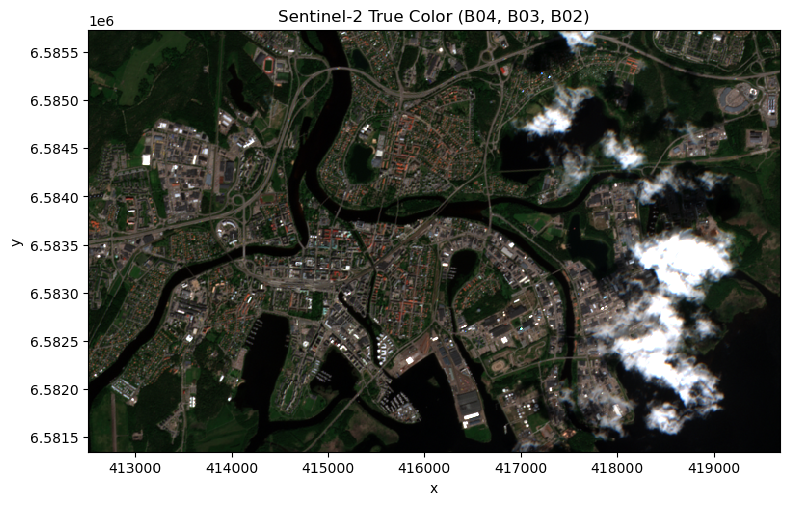

In [2]:
# Load a single scene from the time range (may contain clouds)
datacube = connection.load_collection(
    collection_id='des_s2_msi_l2a',
    spatial_extent=aoi,
    temporal_extent=timespan,
    bands=['B02', 'B03', 'B04', 'B08'],
    properties={'eo:cloud_cover': lambda x: x <= max_cloud_cover},
)

# Take the first available scene
image = datacube.reduce_dimension(dimension='t', reducer='first')
image_tif = image.download(format='GTiff')

# Load into xarray
da = xr.open_dataarray(io.BytesIO(image_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])
da = (da.astype(np.float32) / 10_000).clip(0, 1)

# True color visualization
rgb = da.sel(band=['B04', 'B03', 'B02'])
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rgb.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=ax)
ax.set_aspect('equal')
ax.set_title('Sentinel-2 True Color (B04, B03, B02)')
plt.tight_layout()
plt.show()

## 4. The Sentinel-2 Quality Assurance Information (QAI) Layer

The DES Sentinel-2 Level 2 product includes a **Quality Assurance Information (QAI) Layer** — a per-pixel quality bits generated by the FORCE Level 2 Processing System used for atmospheric correction. There are 12 quality bits (some of them are dual-bit words). We list commonly used ones below:

<table>
<tr><th>Bit No.</th><th>Parameter name</th><th>Bit comb.</th><th>Integer</th><th>State</th></tr>
<tr><td rowspan="4">1-2</td><td rowspan="4">Cloud state</td><td>00</td><td>0</td><td>clear</td></tr>
<tr><td>01</td><td>1</td><td>less confident cloud</td></tr>
<tr><td>10</td><td>2</td><td>confident, opaque cloud</td></tr>
<tr><td>11</td><td>3</td><td>cirrus</td></tr>
<tr><td rowspan="2">3</td><td rowspan="2">Cloud shadow flag</td><td>0</td><td>0</td><td>no</td></tr>
<tr><td>1</td><td>1</td><td>yes</td></tr>
<tr><td rowspan="2">4</td><td rowspan="2">Snow flag</td><td>0</td><td>0</td><td>no</td></tr>
<tr><td>1</td><td>1</td><td>yes</td></tr>
<tr><td rowspan="2">5</td><td rowspan="2">Water flag</td><td>0</td><td>0</td><td>no</td></tr>
<tr><td>1</td><td>1</td><td>yes</td></tr>
</table>

For a full guide to quality bits, please visit the official FORCE documentation: https://force-eo.readthedocs.io/en/latest/howto/qai.html

We can download and visualize the QAI layer corresponding to our image above. It is crucial to use the same parameters when defining the datacube as we used to retrieve the image to obtain the corresponding quality information.

Please note that since we are visualizing quality bits, the image is not directly interpretable. To work with quality bits, we first need to extract information from specific bits we are interested in.

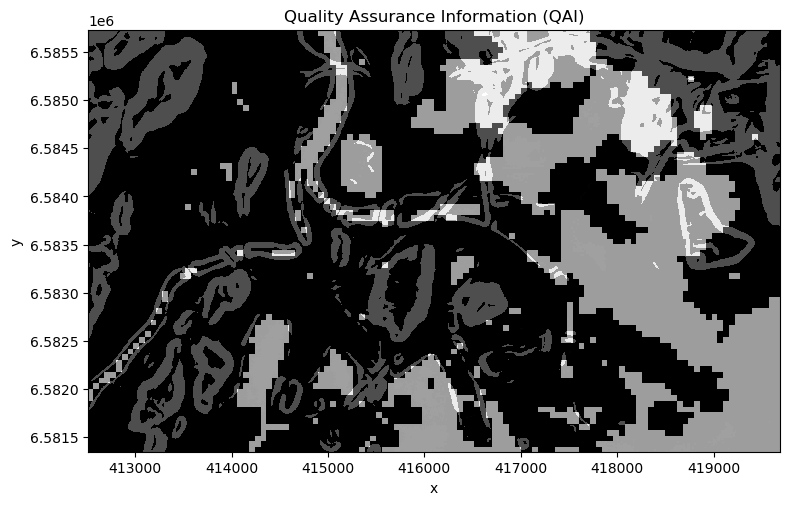

In [3]:
# Load the QAI band for the same area, time range, and scene-level filter
qai_datacube = connection.load_collection(
    collection_id='des_s2_msi_l2a',
    spatial_extent=aoi,
    temporal_extent=timespan,
    bands=['QAI'],
    properties={'eo:cloud_cover': lambda x: x <= max_cloud_cover},
)
    
qai_image = qai_datacube.reduce_dimension(dimension='t', reducer='first')

# Visualize the QAI layer for the Sentinel-2 scene
qai_image_tif = qai_image.download(format='GTiff')
da = xr.open_dataarray(io.BytesIO(qai_image_tif), engine='rasterio')
da = da.assign_coords(band=['QAI'])
quality_bits = da.sel(band='QAI')

# Vizualize 
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
quality_bits.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
ax.set_aspect('equal')
ax.set_title('Quality Assurance Information (QAI)')
plt.tight_layout()
plt.show()

## 5. Building a cloud mask

A **mask** in openEO is a binary datacube where:
- `True` (1) → pixel is **masked out** (excluded from analysis)
- `False` (0) → pixel is **kept** (included in analysis)

As shown in the bit table for the QAI layer, bits 1–2 together form a 2-bit "cloud state" field with four possible values: 0 = clear, 1 = less confident cloud, 2 = confident/opaque cloud, 3 = cirrus.

To isolate this field, we right-shift the QAI value by 1 bit (moving the cloud-state bits down to positions 0–1) and then mask with 3 (binary 11) to zero out any other flags — such as cloud shadow or snow — that live at higher bit positions.

This gives us a clean value of 0–3 that we can compare directly.

We create a cloud mask that marks pixels as masked (1) wherever the cloud state is 2 (confident, opaque cloud).

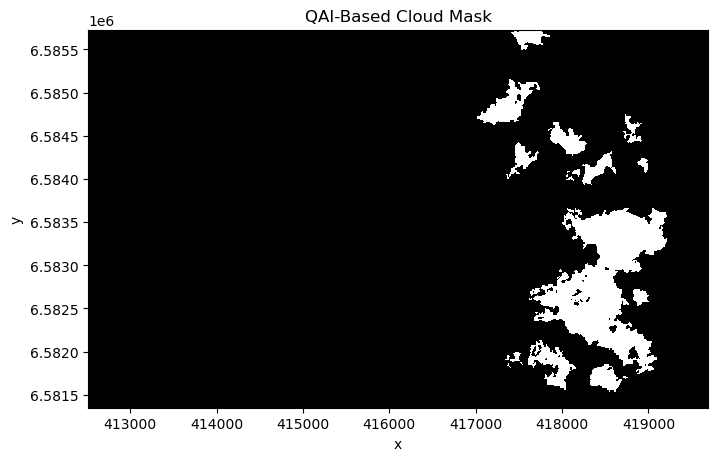

In [4]:
def create_cloud_mask(qai_band):
    # Bits 1 and 2 are cloud state bits -> shift bits one bit to the right
    shifted = qai_band.process('bitwise_right_shift', x=qai_band, y=1)
    # Isolate the two bits using a bit mask (binary 11 is 3)
    cloud_state = shifted.process('bitwise_and', x=shifted, y=3)
    # Create a cloud mask for confident, opaque clouds (integer value 2)
    cloud_mask = cloud_state == 2
    return cloud_mask

cloud_mask = create_cloud_mask(qai_image.band('QAI'))

# Visualize the QAI layer for the Sentinel-2 scene
cloud_mask_tif = cloud_mask.download(format='GTiff')
da = xr.open_dataarray(io.BytesIO(cloud_mask_tif), engine='rasterio')
da = da.assign_coords(band=['QAI'])
qai = da.sel(band='QAI')

# Vizualize 
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
qai.plot.imshow(ax=ax, cmap='gray', add_colorbar=False)
ax.set_aspect('equal')
ax.set_title('QAI-Based Cloud Mask')
plt.show()

## 6. Apply the cloud mask

The mask is then applied to the spectral datacube using `.mask()`, which sets masked pixels to NoData (NaN). These NaN values are automatically ignored in subsequent processing (for example, by reducers).

It should be noted that the QAI layer has a native resolution of **20 m** (compared to 10 m for the visible and NIR bands), so we need to resample it to match the spectral bands before applying the mask.

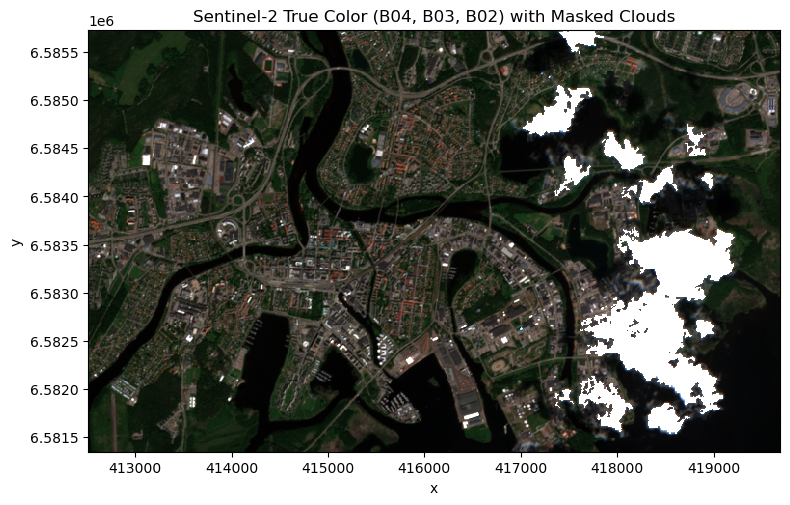

In [5]:
# Resample QAI (20 m) to match the RGB datacube (10 m)
cloud_mask_resampled = cloud_mask.resample_cube_spatial(image)

# Apply the mask: masked pixels become NaN / NoData
masked_image = image.mask(cloud_mask_resampled)

masked_image_tif = masked_image.download(format='GTiff')

# Load into xarray
da = xr.open_dataarray(io.BytesIO(masked_image_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])
da = (da.astype(np.float32) / 10_000).clip(0, 1)

# True color visualization
rgb = da.sel(band=['B04', 'B03', 'B02'])
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rgb.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=ax)
ax.set_aspect('equal')
ax.set_title('Sentinel-2 True Color (B04, B03, B02) with Masked Clouds')
plt.tight_layout()
plt.show()

## 7. Creating the cloud-free composite

With the cloud mask applied, we now reduce the time dimension using the **median** reducer.

For each pixel location, the median is computed from all valid (non-masked) observations across the time series. Because clouds appear as very bright values and shadows as very dark values, the median naturally excludes both extremes and selects a representative clear-sky observation.

The result is a **single composite image** — as if we took all the cloud-free pixels from June 2026 and merged them into one seamless scene.

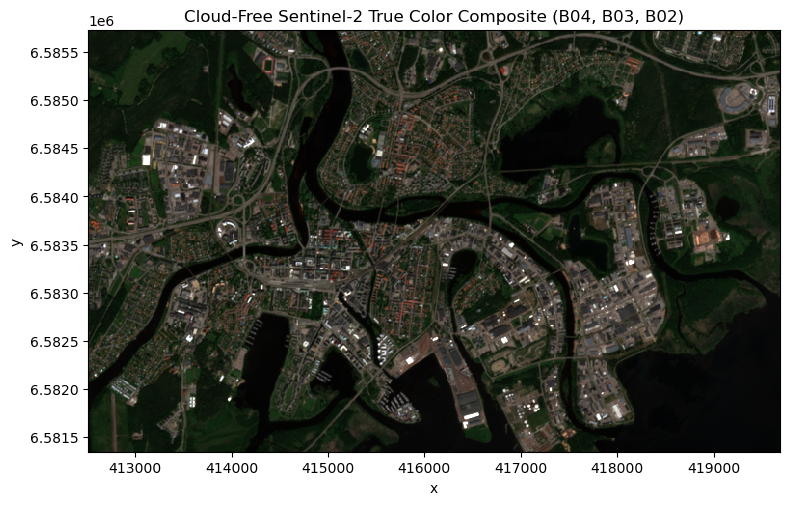

In [6]:
cloud_mask_datacube = qai_datacube.band('QAI').apply(lambda x: create_cloud_mask(x))

# Resample QAI (20 m) to match the RGB datacube (10 m)
cloud_mask_datacube_resampled = cloud_mask_datacube.resample_cube_spatial(datacube)

# Apply the mask: masked pixels become NaN / NoData
datacube_masked = datacube.mask(cloud_mask_datacube_resampled)

composite = datacube_masked.reduce_dimension(dimension='t', reducer='median')

# Download and display the cloud-free composite
composite_tif = composite.download(format='GTiff')

# Load into xarray
da = xr.open_dataarray(io.BytesIO(composite_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])

# True color visualization
rgb = da.sel(band=['B04', 'B03', 'B02'])
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rgb.plot.imshow(rgb='band', vmin=0, vmax=4_000, ax=ax)
ax.set_aspect('equal')
ax.set_title('Cloud-Free Sentinel-2 True Color Composite (B04, B03, B02)')
plt.tight_layout()
plt.show()

## 7. Cloud-free NDVI composite over land

The same workflow applies to any spectral band combination. Here we build a cloud-free NDVI composite by:
1. Computing NDVI per time step.
2. Performing additional masking of low-quality observations.
3. Taking the mean NDVI over time.

The result is a high-quality NDVI product:

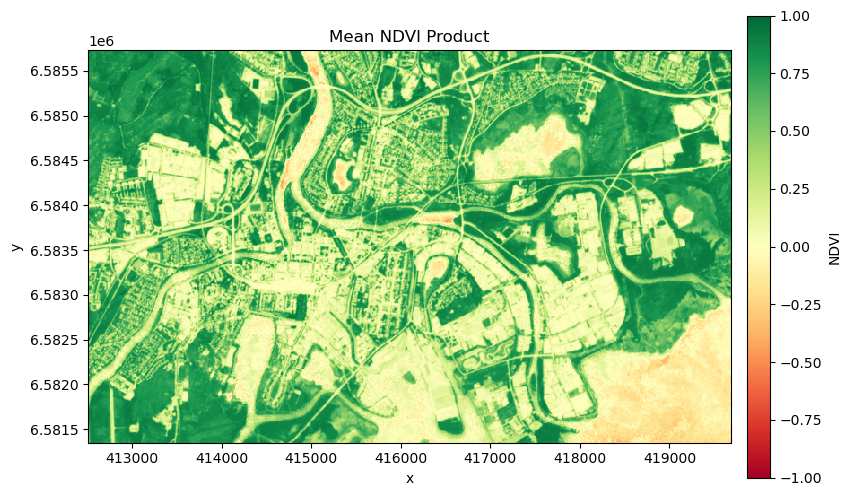

In [7]:
# Computing NDVI for each scene in the datacube, as learned in Session 3
ndvi_datacube = datacube_masked.ndvi(nir='B08', red='B04')

# Performing additional masking of low-quality (subzero and saturation) pixels
# The procedure is identical to cloud masking, but different bit information is isolated
def extract_bit(band, bit_position):
    shifted = band.process('bitwise_right_shift', x=band, y=bit_position)
    return shifted.process('bitwise_and', x=shifted, y=1)

def create_quality_mask(qai_band):
    subzero_mask = extract_bit(qai_band, 8) == 1
    saturation_mask = extract_bit(qai_band, 9) == 1
    
    quality_mask = subzero_mask.process('or', x=subzero_mask, y=saturation_mask)
    
    return quality_mask

# Apply the quality mask to the NDVI datacube
quality_mask_datacube = qai_datacube.band('QAI').apply(lambda x: create_quality_mask(x))
quality_mask_datacube_resampled = quality_mask_datacube.resample_cube_spatial(ndvi_datacube)
ndvi_datacube = ndvi_datacube.mask(quality_mask_datacube_resampled)

# Compute NDVI across high-quality observations
ndvi_composite = ndvi_datacube.reduce_dimension(dimension='t', reducer='mean')

# Download and display the NDVI product
ndvi_tif = ndvi_composite.download(format='GTiff')
ndvi_da = xr.open_dataarray(io.BytesIO(ndvi_tif), engine='rasterio')
ndvi_da = ndvi_da.squeeze()  # Drop any singleton band dimension

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
cbar_kwargs={'shrink': 0.6, 'aspect': 20, 'pad': 0.02, 'label': 'NDVI'}
ndvi_da.plot.imshow(ax=ax, cmap='RdYlGn', cbar_kwargs=cbar_kwargs, vmin=-1, vmax=1)
ax.set_aspect('equal')
ax.set_title('Mean NDVI Product')
plt.show()

---

## Summary

In this session you:

- Understood why cloud contamination is the primary challenge in optical EO over Sweden.
- Learned how masking works: setting pixels to NoData based on a binary condition.
- Used the FORCE Quality Assurance Information to identify cloud pixels.
- Built a cloud mask and applied it to a spectral datacube using `.mask()`.
- Combined masking with median temporal reduction to produce a clean composite.
- Applied the same workflow to NDVI to create a high-quality NDVI product.

**Next session (Session 6):** we use the cloud-free composite as input to a Random Forest machine learning classifier to produce a finished urban green map of Stockholm — the culmination of the entire MOOC.

---
*Digital Earth Sweden MOOC — Session 5 of 6*